In [1]:
import open3d as o3d
import numpy as np
import os
import pandas as pd
import sys
import matplotlib.pyplot as plt
# Add current working directory to sys.path
sys.path.append(os.getcwd())

from tools import ICP, utils


gts = pd.read_csv("dataset/ground_truth.csv")

# --- Load map ---
map_pcd = o3d.io.read_point_cloud("dataset/map.pcd")
map_np = np.asarray(map_pcd.points)

print(gts)
print(f"Current working directory: {os.getcwd()}")


      Frame        x        y         z      roll     pitch       yaw
0         0    0.000  0.00000  0.000000  0.000000  0.000000  0.000000
1         1    0.000  0.00000  0.015636  0.000000  0.000000  0.000000
2         2    0.000  0.00000  0.005846  0.000000  0.000000  0.000000
3         3    0.000  0.00000  0.005628  0.000000  0.000000  0.000000
4         4    0.000  0.00000  0.005628  0.000000  0.000000  0.000000
...     ...      ...      ...       ...       ...       ...       ...
1009   1009  182.299  5.29271 -0.018730 -0.029093 -0.014225  0.019378
1010   1010  182.299  5.27850 -0.023267 -0.030727 -0.015000  0.019204
1011   1011  182.299  5.28007 -0.014406 -0.028470 -0.012781  0.019203
1012   1012  182.299  5.27980 -0.023047 -0.035554 -0.017184  0.019364
1013   1013  182.299  5.28085 -0.024493 -0.030387       NaN       NaN

[1014 rows x 7 columns]
Current working directory: /app/Examples


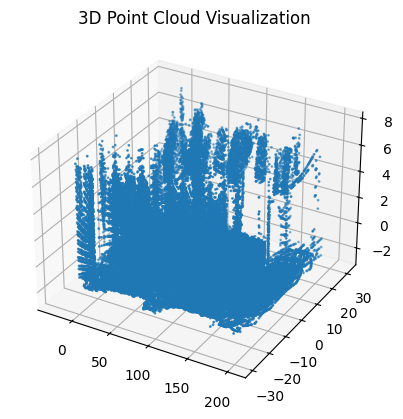

In [17]:
# Plot the point cloud
points = np.asarray(map_pcd.points)

# Plot with Matplotlib
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1)
plt.title("3D Point Cloud Visualization")
plt.show()

In [2]:

def downsample_voxel(map_array: np.ndarray, voxel_size: float):
    """
    Downsamples a pointcloud using a voxel grid, and provides voxel configurations.

    Args:
    - map_pcd_arr (np.ndarray): Input point cloud as an Nx3 numpy array.
    - voxel_size (float): Desired voxel size for downsampling.

    Returns:
    - Tuple[np.ndarray, dict]: Downsampled point cloud as an Nx3 numpy array,
                               and a dictionary with voxel configuration details.
    """
    # Convert np array to open3D pointcloud
    map_pcd = o3d.geometry.PointCloud()
    map_pcd.points = o3d.utility.Vector3dVector(map_array)
    
    # Use open3D voxelisation utility with desired voxel_size
    voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(map_pcd, voxel_size)
    
    # Get coordinates of the voxels that are points of the downsampled grid
    indices = np.array([voxel.grid_index for voxel in voxel_grid.get_voxels()], dtype=float) * voxel_size

    # Calculate voxel configuration details
    max_bound = voxel_grid.get_max_bound()
    min_bound = voxel_grid.get_min_bound()
    voxel_config = {
        'voxel_bounds': {'min': 0, 'max': indices.max(axis=0)},
        'real_bounds': {'min': min_bound, 'max': max_bound}
    }

    # Adjust indices to represent real-world coordinates (center of each voxel)
    indices += min_bound + voxel_size / 2

    return indices, voxel_config


In [3]:
def preprocess_pcd(pcd, voxel_size=0.5):
    return pcd.voxel_down_sample(voxel_size=voxel_size)

def rigid_transformation(cloud: np.ndarray, R: np.ndarray, t: np.ndarray) -> np.ndarray:
    """
    Applies a rigid transformation to a point cloud.
    
    Parameters:
        cloud (np.ndarray): A point cloud array of shape (n_points, 3).
        R (np.ndarray): Rotation matrix of shape (3, 3).
        t (np.ndarray): Translation vector of shape (3, 1).
    
    Returns:
        np.ndarray: Transformed point cloud of shape (n_points, 3).
    """
    # Validate input types
    if not isinstance(cloud, np.ndarray):
        raise TypeError("The point cloud must be a numpy array.")
    if not isinstance(R, np.ndarray):
        raise TypeError("The rotation matrix must be a numpy array.")
    if not isinstance(t, np.ndarray):
        raise TypeError("The translation vector must be a numpy array.")

    # Validate input dimensions
    if cloud.ndim != 2 or cloud.shape[1] != 3:
        raise ValueError("Point cloud shape must be (n_points, 3).")
    if R.shape != (3, 3):
        raise ValueError("Rotation matrix must have shape (3, 3).")
    if t.shape != (3, 1):
        raise ValueError("Translation vector must have shape (3, 1).")

    # Validate matrix compatibility
    if cloud.shape[1] != R.shape[0]:
        raise ValueError("The number of columns in the point cloud must match the number of rows in the rotation matrix.")
    
    return (R @ cloud.T + t).T


In [4]:
# Get position and orientation for a specific frame
FRAME = 50
gt = gts.iloc[FRAME]

# Extract the row and use direct slicing to create numpy arrays
gt = gts.iloc[FRAME]
pos = gt[[' x', ' y', ' z']].to_numpy()
orientation = gt[[' roll', ' pitch', ' yaw']].to_numpy()

# Print position and orientation arrays
print(f"Position: {pos}")
print(f"Orientation: {orientation}")


Position: [4.28331    0.0609112  0.00704979]
Orientation: [-4.26106e-06 -8.84533e-05  4.61252e-04]


In [5]:
from scipy.spatial.transform import Rotation as R

def pose_to_transformation(pose):
    translation = np.array(pose[:3])
    r = R.from_euler('xyz', pose[3:])
    transformation = np.eye(4)
    transformation[:3, :3] = r.as_matrix()
    transformation[:3, 3] = translation
    return transformation


In [12]:
import time

# --- Utility: Euler to transformation ---
def pose_to_transformation(pose):
    x, y, z = pose[[' x', ' y', ' z']].to_numpy()
    roll, pitch, yaw = pose[[' roll', ' pitch', ' yaw']].to_numpy()

    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll),  np.cos(roll)],
    ])
    Ry = np.array([
        [np.cos(pitch), 0, np.sin(pitch)],
        [0, 1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)],
    ])
    Rz = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1],
    ])

    R = Rz @ Ry @ Rx
    t = np.array([[x], [y], [z]])

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3:] = t
    return T

# --- ICP setup ---
icp = ICP(max_iterations=50, max_dist=1.5, tol=1e-5)
frame_folder = "dataset/frames"
num_frames = min(len(gts), 1014)  

pose_history = []
error_list = []
timing_list = []  # ← New list to store computation time per frame

# Start from frame 0 ground truth pose
initial_pose = gts.iloc[0]
current_trans = pose_to_transformation(initial_pose)

for i in range(num_frames):
    frame_path = os.path.join(frame_folder, f"frame_{i}.pcd")
    if not os.path.exists(frame_path):
        print(f"⚠️ Frame not found: {frame_path}")
        continue

    scan_pcd = o3d.io.read_point_cloud(frame_path)
    scan_np = np.asarray(scan_pcd.points)

    # Transform scan using previous estimate
    transformed_scan = rigid_transformation(scan_np, current_trans[:3, :3], current_trans[:3, 3].reshape(3, 1))

    if scan_np.shape[0] == 0:
        print(f"Empty scan at frame {i}. Skipping...")
        continue

    valid_mask = np.isfinite(transformed_scan).all(axis=1)
    transformed_scan = transformed_scan[valid_mask]

    if transformed_scan.shape[0] == 0:
        print(f"All transformed points are invalid at frame {i}. Skipping...")
        continue

    # ⏱️ Start timing
    start_time = time.time()

    # Apply ICP
    R, t, *_ = icp.align(transformed_scan, map_np)

    # ⏱️ End timing and store duration
    duration = time.time() - start_time
    timing_list.append(duration)

    # Update transformation
    current_trans[:3, :3] = R @ current_trans[:3, :3]
    current_trans[:3, 3:] = R @ current_trans[:3, 3:] + t

    pose_history.append(current_trans.copy())

    # Compute error vs GT
    gt_pose = pose_to_transformation(gts.iloc[i][[' x', ' y', ' z', ' roll', ' pitch', ' yaw']])

    est_position = current_trans[:3, 3]
    gt_position = gt_pose[:3, 3]
    error = np.linalg.norm(est_position - gt_position)
    error_list.append(error)

    if error > 1.2:
        print(f"Frame {i} exceeded error threshold: {error:.2f}m")

# Summary
print("Finished ICP localization.")
print(f"Avg error: {np.mean(error_list):.2f}m")
print(f"Avg time per frame: {np.mean(timing_list):.4f}s")


Finished ICP localization.
Avg error: 0.45m
Avg time per frame: 0.6253s


In [16]:
print(f"Maximum Computation Time: {np.max(timing_list):.2f} s")


Maximum Computation Time: 1.11 s


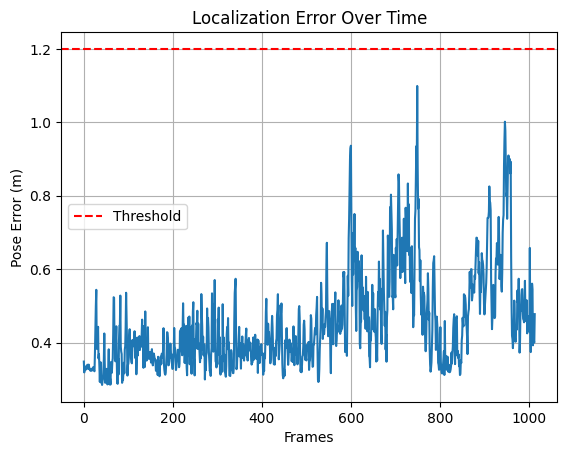

In [8]:
import matplotlib.pyplot as plt

plt.plot(error_list)
plt.axhline(1.2, color='r', linestyle='--', label='Threshold')
plt.title("Localization Error Over Time")
plt.xlabel("Frames")
plt.ylabel("Pose Error (m)")
plt.legend()
plt.grid()
plt.show()


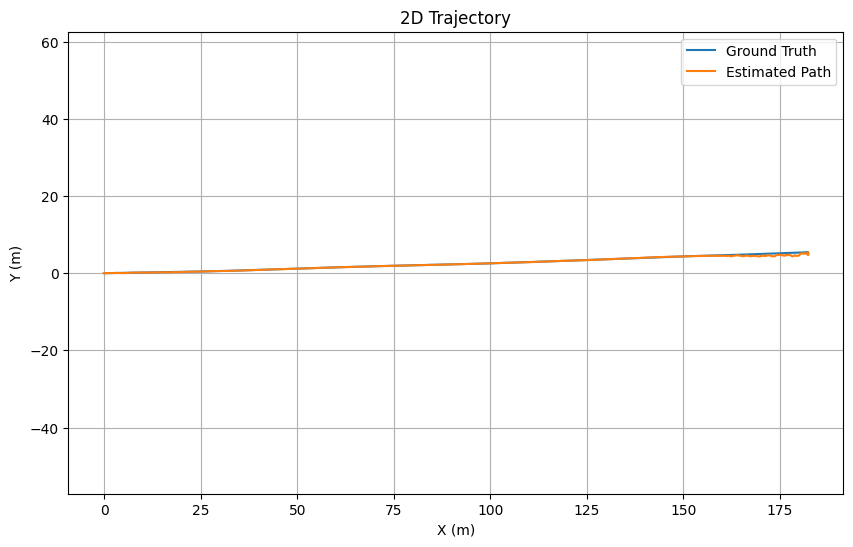

In [9]:
# Assume pose_history was already computed using ICP
# If not, run the ICP alignment loop and populate it
try:
    pose_history  # Check if pose_history exists
except NameError:
    print("⚠️ 'pose_history' is not defined. Please run the ICP alignment loop first.")
    sys.exit(1)

estimated_positions = np.array([pose[:3, 3] for pose in pose_history])
ground_truth_positions = np.array([
    pose_to_transformation(gts.iloc[i])[:3, 3] for i in range(len(pose_history))
])

plt.figure(figsize=(10, 6))
plt.plot(ground_truth_positions[:, 0], ground_truth_positions[:, 1], label="Ground Truth")
plt.plot(estimated_positions[:, 0], estimated_positions[:, 1], label="Estimated Path")
plt.title("2D Trajectory")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


In [11]:
print(f"ICP Summary:")
print(f"Average Pose Error: {np.mean(error_list):.2f} m")
print(f"Maximum Pose Error: {np.max(error_list):.2f} m")
print(f"Frames above 1.2m error: {sum(e > 1.2 for e in error_list)} / {len(error_list)}")


ICP Summary:
Average Pose Error: 0.45 m
Maximum Pose Error: 1.10 m
Frames above 1.2m error: 0 / 1014
